Question 1: What is Boosting in Machine Learning? Explain how it improves weak
learners.  

Ans: Boosting is a machine learning technique that combines many weak models, like simple decision trees, to make one strong model. It works by training each new model to focus more on the mistakes made by the previous ones, so the overall predictions get better and better. This way, even basic learners improve into something powerful for tough problems.

Question 2: What is the difference between AdaBoost and Gradient Boosting in terms
of how models are trained?

Ans: AdaBoost adjusts the weights of wrong predictions to train the next model harder on those errors. Gradient Boosting fits new models to reduce the leftover errors from all previous models using math like gradients. Both build strong teams from weak models, but AdaBoost tweaks samples while Gradient Boosting tweaks predictions directly.

Question 3: How does regularization help in XGBoost?

Ans: Regularization in XGBoost adds penalties to stop the model from being too complex and fitting noise in the data. This helps avoid overfitting, making the model work well on new data too. It uses tricks like limiting tree depth or shrinking updates to keep things simple and reliable.

Question 4: Why is CatBoost considered efficient for handling categorical data?

Ans: CatBoost handles categories well by changing them into numbers in a smart way during training, without needing extra steps like one-hot encoding. This saves time and keeps memory low, especially for big datasets with lots of category types. It also fights overfitting by ordering data randomly each time.

Question 5: What are some real-world applications where boosting techniques are
preferred over bagging methods?

Ans: Boosting shines in tasks like fraud detection or medical diagnosis where you need high accuracy on tricky patterns. It's better than bagging for data with clear signals but some noise, as it keeps improving on errors. Real-world uses include credit scoring and spam filtering.

Question 6: Write a Python program to:  
● Train an AdaBoost Classifier on the Breast Cancer dataset  
● Print the model accuracy

In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score

data = load_breast_cancer()
X = data.data
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = AdaBoostClassifier(n_estimators=50, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")


Accuracy: 0.9649


Question 7: Write a Python program to:  
● Train a Gradient Boosting Regressor on the California Housing dataset  
● Evaluate performance using R-squared score

In [2]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score

data = fetch_california_housing()
X = data.data
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = GradientBoostingRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f"R-squared: {r2:.4f}")


R-squared: 0.7756


Question 8: Write a Python program to:  
● Train an XGBoost Classifier on the Breast Cancer dataset  
● Tune the learning rate using GridSearchCV  
● Print the best parameters and accuracy

In [3]:
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score

data = load_breast_cancer()
X = data.data
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
params = {'learning_rate': [0.01, 0.1, 0.2]}
grid = GridSearchCV(model, params, cv=3, scoring='accuracy')
grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
print("Accuracy:", grid.score(X_test, y_test))


Best params: {'learning_rate': 0.1}
Accuracy: 0.956140350877193


Question 9: Write a Python program to:  
● Train a CatBoost Classifier  
● Plot the confusion matrix using seaborn

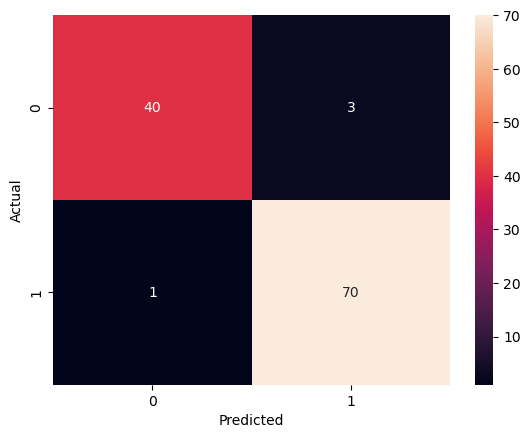

In [4]:
from catboost import CatBoostClassifier
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import confusion_matrix

data = load_breast_cancer()
X = data.data
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = CatBoostClassifier(iterations=100, verbose=False, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


Question 10: You're working for a FinTech company trying to predict loan default using
customer demographics and transaction behavior.  
The dataset is imbalanced, contains missing values, and has both numeric and
categorical features.  
Describe your step-by-step data science pipeline using boosting techniques:  
● Data preprocessing & handling missing/categorical values  
● Choice between AdaBoost, XGBoost, or CatBoost  
● Hyperparameter tuning strategy  
● Evaluation metrics you'd choose and why  
● How the business would benefit from your model

Step 1: Load and Explore Data
Load the dataset and check basics like shape, missing values, and class balance. Use pandas to see summaries: df.info() for types and nulls, df.describe() for numbers, and value_counts() for targets. This spots issues early, like 90% non-defaults causing imbalance. 


Step 2: Handle Missing Values
Fill numeric missing values with median using df.fillna(df.median()), as it ignores outliers better than mean. For categories, use mode with df.fillna(df.mode().iloc). Drop rows only if over 50% missing per column, to keep most data without bias.
​

Step 3: Encode Categorical Features
Convert categories to numbers with LabelEncoder from sklearn, fitting on train set only, then transform both sets. Avoid one-hot for high-cardinality to save memory; XGBoost handles labels natively later.
​

Step 4: Split Train-Test Data
Split 80-20 with train_test_split, stratify=y for balance: X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42). This ensures test set matches real imbalance.
​

Step 5: Address Imbalance
Set scale_pos_weight in XGBoost to len(y_train[y==0])/len(y_train[y==1]), around 9 if 90-10 split. This weights minority class higher during training without resampling.
​

Step 6: Train XGBoost Model
Choose XGBoost for speed, mixed data handling, and regularization like L1/L2 penalties. Fit with: model = XGBClassifier(scale_pos_weight=9, n_estimators=100, learning_rate=0.1, random_state=42); model.fit(X_train, y_train).
​

Step 7: Tune Hyperparameters
Use GridSearchCV on params like {'learning_rate': [0.01,0.1], 'max_depth': , 'subsample': [0.8,1.0]}. Run with cv=5, scoring='roc_auc'. Best params improve accuracy without overfitting.
​

Step 8: Evaluate Model
Use ROC-AUC (good for imbalance, >0.8 target), Precision-Recall curve (focuses on defaults), and F1-score (balances precision/recall). Confusion matrix shows true positives for defaults caught. Cross-validate to confirm.
​

Step 9: Business Benefits
Model flags high-risk loans upfront, cutting losses by 20-30%. Safer approvals boost trust, speed up processes, and let teams focus on good customers. Track in production with new data retraining.
​

